# 04 - Pré-processamento: Perfil por Setor Censitário

Agrega o Censo 2022 por `COD_SETOR`, calculando a proporção de cada tipo de endereço (`COD_ESPECIE`) e o centróide geográfico. O resultado é o vetor de features que alimentará o clustering.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from pathlib import Path

con = duckdb.connect()
CENSO = "'../data/censo 2022/29_BA.parquet'"
OUTPUT_DIR = Path('../outputs')

In [2]:
# Agrega por setor: proporção de cada COD_ESPECIE + centróide + total
df_setores = con.execute(f"""
    SELECT
        COD_SETOR,
        COUNT(*) AS total_enderecos,
        AVG(LATITUDE)  AS lat_centroide,
        AVG(LONGITUDE) AS lon_centroide,

        -- Proporção de cada espécie
        SUM(CASE WHEN COD_ESPECIE = 1 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_domicilio_particular,
        SUM(CASE WHEN COD_ESPECIE = 2 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_domicilio_coletivo,
        SUM(CASE WHEN COD_ESPECIE = 3 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_estab_agropecuario,
        SUM(CASE WHEN COD_ESPECIE = 4 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_estab_ensino,
        SUM(CASE WHEN COD_ESPECIE = 5 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_estab_saude,
        SUM(CASE WHEN COD_ESPECIE = 6 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_estab_outras,
        SUM(CASE WHEN COD_ESPECIE = 7 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_construcao,
        SUM(CASE WHEN COD_ESPECIE = 8 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_estab_religioso,

        -- Proporção por finalidade de construção
        SUM(CASE WHEN COD_INDICADOR_FINALIDADE_CONST = 1 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_finalidade_residencial,
        SUM(CASE WHEN COD_INDICADOR_FINALIDADE_CONST = 2 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_finalidade_comercial,
        SUM(CASE WHEN COD_INDICADOR_FINALIDADE_CONST = 3 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_finalidade_mista

    FROM read_parquet({CENSO})
    WHERE LATITUDE IS NOT NULL AND LONGITUDE IS NOT NULL
    GROUP BY COD_SETOR
    HAVING COUNT(*) >= 5
""").df()

print(f'Setores: {len(df_setores):,}')
df_setores.head()

Setores: 30,355


,COD_SETOR,total_enderecos,lat_centroide,lon_centroide,prop_domicilio_particular,prop_domicilio_coletivo,prop_estab_agropecuario,prop_estab_ensino,prop_estab_saude,prop_estab_outras,prop_construcao,prop_estab_religioso,prop_finalidade_residencial,prop_finalidade_comercial,prop_finalidade_mista
0,291840705000165P,195,-9.421509,-40.501849,0.692308,0.005128,0.0,0.000000,0.020513,0.235897,0.041026,0.005128,0.041026,0.000000,0.0
1,291840705000088P,350,-9.427444,-40.506557,0.962857,0.000000,0.0,0.000000,0.000000,0.014286,0.020000,0.002857,0.002857,0.000000,0.0
2,290100705000014P,792,-13.027812,-39.609417,0.877525,0.000000,0.0,0.003788,0.000000,0.056818,0.055556,0.006313,0.047980,0.001263,0.0
3,290560205000044P,376,-15.424717,-39.495352,0.771277,0.002660,0.0,0.002660,0.000000,0.148936,0.069149,0.005319,0.050532,0.010638,0.0
4,291080005110174P,254,-12.287674,-38.931778,0.948819,0.000000,0.0,0.000000,0.003937,0.027559,0.015748,0.003937,0.015748,0.000000,0.0


In [3]:
# Verificar nulos após agregação
print("Nulos por coluna:")
print(df_setores.isnull().sum())
df_setores = df_setores.dropna()
print(f'\nSetores após remover nulos: {len(df_setores):,}')

Nulos por coluna:
COD_SETOR                      0
total_enderecos                0
lat_centroide                  0
lon_centroide                  0
prop_domicilio_particular      0
prop_domicilio_coletivo        0
prop_estab_agropecuario        0
prop_estab_ensino              0
prop_estab_saude               0
prop_estab_outras              0
prop_construcao                0
prop_estab_religioso           0
prop_finalidade_residencial    0
prop_finalidade_comercial      0
prop_finalidade_mista          0
dtype: int64

Setores após remover nulos: 30,355


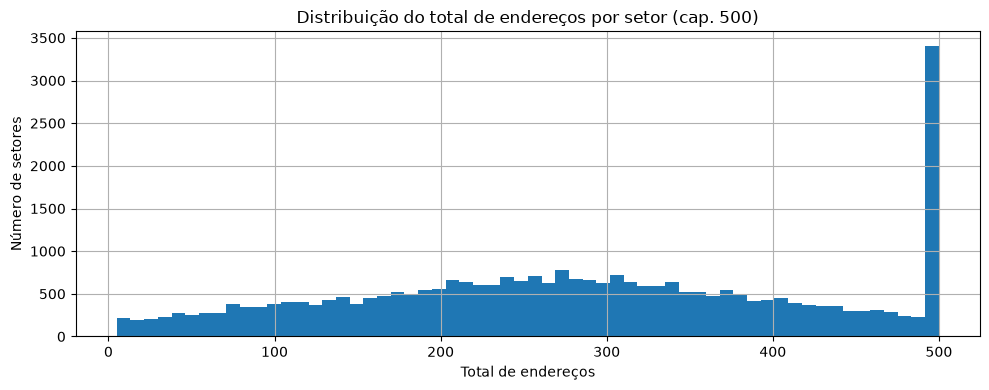

In [4]:
# Distribuição do total de endereços por setor
plt.figure(figsize=(10, 4))
df_setores['total_enderecos'].clip(upper=500).hist(bins=60)
plt.title('Distribuição do total de endereços por setor (cap. 500)')
plt.xlabel('Total de endereços')
plt.ylabel('Número de setores')
plt.tight_layout()
plt.savefig('../outputs/figures/distribuicao_enderecos_setor.png', dpi=150)
plt.show()

In [5]:
# Normalização das features (exceto COD_SETOR e coordenadas)
FEATURES = [
    'prop_domicilio_particular', 'prop_domicilio_coletivo',
    'prop_estab_agropecuario', 'prop_estab_ensino', 'prop_estab_saude',
    'prop_estab_outras', 'prop_construcao', 'prop_estab_religioso',
    'prop_finalidade_residencial', 'prop_finalidade_comercial', 'prop_finalidade_mista'
]

scaler = StandardScaler()
X = scaler.fit_transform(df_setores[FEATURES])
X_df = pd.DataFrame(X, columns=FEATURES, index=df_setores.index)

print(f'Shape do array de features: {X.shape}')
X_df.describe().round(3)

Shape do array de features: (30355, 11)


,prop_domicilio_particular,prop_domicilio_coletivo,prop_estab_agropecuario,prop_estab_ensino,prop_estab_saude,prop_estab_outras,prop_construcao,prop_estab_religioso,prop_finalidade_residencial,prop_finalidade_comercial,prop_finalidade_mista
count,30355.000,30355.000,30355.000,30355.000,30355.000,30355.000,30355.000,30355.000,30355.000,30355.000,30355.000
mean,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,0.000,0.000,-0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-5.318,-0.085,-0.549,-0.444,-0.295,-1.152,-1.044,-0.816,-0.917,-0.399,-0.255
25%,-0.625,-0.085,-0.549,-0.444,-0.295,-0.635,-0.641,-0.816,-0.645,-0.399,-0.255
50%,0.185,-0.085,-0.549,-0.215,-0.295,-0.242,-0.222,-0.218,-0.243,-0.399,-0.255
75%,0.718,-0.085,0.099,0.198,0.020,0.347,0.364,0.403,0.333,0.111,-0.255
max,1.678,76.374,7.228,58.791,57.630,9.310,21.563,48.573,25.161,45.787,32.872


In [6]:
# Salvar dataset de setores + features normalizadas
df_out = df_setores[['COD_SETOR', 'total_enderecos', 'lat_centroide', 'lon_centroide']].copy()
df_out[FEATURES] = X

df_out.to_parquet(OUTPUT_DIR / 'setores_features.parquet', index=False)
print(f'Salvo: outputs/setores_features.parquet  ({len(df_out):,} setores, {len(FEATURES)} features)')

Salvo: outputs/setores_features.parquet  (30,355 setores, 11 features)
